In [1]:
from langchain_nvidia_ai_endpoints import ChatNVIDIA , NVIDIAEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document

from langgraph.graph import StateGraph , START , END

from dotenv import load_dotenv
from pydantic import BaseModel , Field
from typing import TypedDict , List , Literal

import time

d:\GenAI\LangGraph\myenvAI\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
docs = (

    PyPDFLoader(r'D:\GenAI\LangGraph\document\Company_Policies.pdf').load() + 
    PyPDFLoader(r'D:\GenAI\LangGraph\document\Company_Profile.pdf').load() + 
    PyPDFLoader(r'D:\GenAI\LangGraph\document\Company_Policies.pdf').load()
)

In [4]:
# Text splitting
chunk = RecursiveCharacterTextSplitter(chunk_size = 600 , chunk_overlap = 150).split_documents(docs)

In [5]:
embedding = NVIDIAEmbeddings()
vector_store = FAISS.from_documents(chunk , embedding)
retriever = vector_store.as_retriever(search_kwargs = {'k' : 4})

In [6]:
llm = ChatNVIDIA(model = 'openai/gpt-oss-120b')

In [20]:
# Define state
class State(TypedDict):
    question : str
    need_retrieval : bool
    docs : List[Document]
    answer : str

In [21]:
class RetrieverDecision(BaseModel):
    should_retrieve : bool = Field(... , description='True if external documents are needed to answer relaibly, else False')


decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            'system',
            'You decide whether retrieval is needed.\n'
            'Return JSON that matches this schema:\n'
            '{{should_retrieve : boolan}}\n\n'
            'Guidelines:\n'
            '- Should_retrieve=True if answering requires specific facts, citations , info likely not in the model.\n'
            '- Should_retrieve=False for general explanations , definations, or reasoning that does not need source.\n'
            '- If unsure , choose True'
        ),
        ('human' , 'Question : {question}'),
    ]
)

# IMPORTANT : no content for structure output
should_retrieve_llm = llm.with_structured_output(RetrieverDecision)


def decide_retrieval(state : State):

    decision : RetrieverDecision = should_retrieve_llm.invoke(

        decide_retrieval_prompt.format_messages(question= state['question'])
    )

    return {'need_retrieval' : decision.should_retrieve}

In [22]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            'system',
            'Answer the question using only your general knowledge.\n'
            'Do NOT assume access to external documents.\n'
            'If you unsure or the answer require specific sources, say:\n'
            'I do not know based on my general knowledge.'
        ),
        ('human' , '{question}')
    ]
)

def generate_direct(state : State):

    out = llm.invoke(

        direct_generation_prompt.format_messages(question = state['question'])
    )

    return {'answer' : out.content}

In [23]:
def retrieve(state : State):

    return {'docs' : retriever.invoke(state['question'])}

In [24]:
def route_after_decide(state : State) -> Literal['generate_direct' , 'retrieve']:

    if state['need_retrieval']:
        return 'retrieve'
    
    else:
        return 'generate_direct'

In [25]:
builder = StateGraph(State)

# Add nodes
builder.add_node('decide_retrieval' , decide_retrieval)
builder.add_node('generate_direct' , generate_direct)
builder.add_node('retrieve' , retrieve)

# Add edges
builder.add_edge(START , 'decide_retrieval')

builder.add_conditional_edges(
    'decide_retrieval',

    route_after_decide,
    {
        'generate_direct' : 'generate_direct',
        'retrieve' : 'retrieve'
    }
)

builder.add_edge('generate_direct' , END)
builder.add_edge('retrieve' , END)

# compile the graph

app = builder.compile()

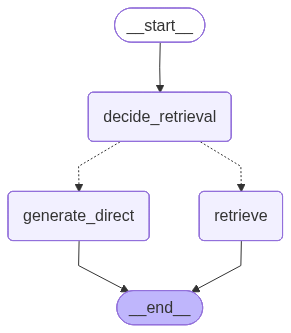

In [26]:
app

In [27]:
result = app.invoke(
    {
        "question": "What is Machine Learning",
        "need_retrieval": False,
        "docs": [],
        "answer": "",
    }
)

print(result["answer"])

**Machine Learning (ML)** is a branch of artificial intelligence that focuses on building systems that can learn from data rather than following only explicitly programmed instructions. In other words, instead of coding a computer to perform every step of a task, developers create algorithms that automatically improve their performance as they are exposed to more examples.

### Core Ideas

| Concept | What it means |
|---------|----------------|
| **Learning from data** | The algorithm receives a set of inputs (features) and, often, corresponding outputs (labels) and discovers patterns or relationships. |
| **Model** | A mathematical representation (e.g., a decision tree, a neural network, a linear equation) that makes predictions or decisions based on new data. |
| **Training** | The process of adjusting the model’s parameters using a training dataset so that it can approximate the desired output. |
| **Inference / Prediction** | Using the trained model to produce outputs for unseen i

In [28]:
result['need_retrieval']

False

In [29]:
result['docs']

[]